# Holiday Planner — Analysis Notebook

**Team:** Sam Willock · Amechi Obisesan · Fenner Backhouse
**Module:** Data Scientist Specialisation — Web Scraping & APIs capstone

This notebook documents the **data pipeline, EDA, scoring model and findings** behind the
Holiday Planner app. It imports the same `src` package the app uses, so the analysis and
the product never drift apart.

**Problem.** Recommend an *adventurous tropical* destination near nightlife (clubs, bars,
restaurants), comparing multiple options on weather, amenities and cost.

> **Reproducibility.** The pipeline calls Open-Meteo (keyless weather), Google Places
> (amenities, key) and a web-scraping price stub, all cached in SQLite. Without keys/network
> it uses deterministic fallbacks so every cell runs; set the keys to switch to live data.

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root on path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src.config import SETTINGS, DEFAULT_WEIGHTS
from src.destinations import load_destinations
from src.pipeline import build_recommendations
from src.scoring import score_destinations, explain
from src.llm import recommend_blurb
plt.rcParams['figure.figsize']=(9,5)
print('Live integrations:', SETTINGS.status())

Live integrations: {'google_places': False, 'llm': False}


## 1. Candidate destinations

In [2]:
catalogue = load_destinations()
print('Candidate destinations:', len(catalogue))
catalogue

Candidate destinations: 12


,city,country,region,lat,lon,avg_flight_gbp,iata
0,Cancun,Mexico,Caribbean,21.1619,-86.8515,520,CUN
1,Bali (Kuta),Indonesia,Southeast Asia,-8.7215,115.1686,680,DPS
2,Phuket,Thailand,Southeast Asia,7.8804,98.3923,640,HKT
3,Rio de Janeiro,Brazil,South America,-22.9068,-43.1729,710,GIG
4,Punta Cana,Dominican Republic,Caribbean,18.5601,-68.3725,560,PUJ
5,Havana,Cuba,Caribbean,23.1136,-82.3666,590,HAV
6,Mombasa,Kenya,East Africa,-4.0435,39.6682,620,MBA
7,Goa,India,South Asia,15.2993,74.1240,560,GOI
8,Montego Bay,Jamaica,Caribbean,18.4762,-77.8939,610,MBJ
9,Boracay (Caticlan),Philippines,Southeast Asia,11.9674,121.9248,720,MPH


## 2. Build the enriched, scored dataset
One call runs the whole pipeline (weather → amenities → price → score).

In [3]:
ranked = build_recommendations(trip_nights=7)
ranked[['city','country','temp_max','humidity','cloud','wind',
        'night_clubs','bars','restaurants','total_cost','adventure_score']].round(1)

,city,country,temp_max,humidity,cloud,wind,night_clubs,bars,restaurants,total_cost,adventure_score
0,Cancun,Mexico,28.9,76.1,35.4,8.1,21,56,30,1262.0,67.4
1,Bali (Kuta),Indonesia,31.0,68.2,20.1,16.0,16,40,36,1044.0,67.1
2,Da Nang,Vietnam,30.3,71.8,28.3,8.0,20,46,26,1502.0,62.1
3,Phuket,Thailand,32.3,74.3,25.1,12.0,12,41,42,1074.0,55.9
4,Boracay (Caticlan),Philippines,32.6,64.5,40.8,14.2,15,51,55,1091.0,54.3
5,Goa,India,32.6,71.5,27.3,10.7,14,19,36,1036.0,51.3
6,Mombasa,Kenya,32.3,82.9,10.7,9.6,14,10,58,1418.0,48.3
7,Havana,Cuba,31.8,81.6,26.6,20.6,6,25,49,961.0,47.0
8,Cartagena,Colombia,28.0,62.3,31.3,14.7,14,55,50,1476.0,46.1
9,Rio de Janeiro,Brazil,29.9,77.3,33.1,9.4,6,19,31,1361.0,44.9


## 3. Exploratory data analysis

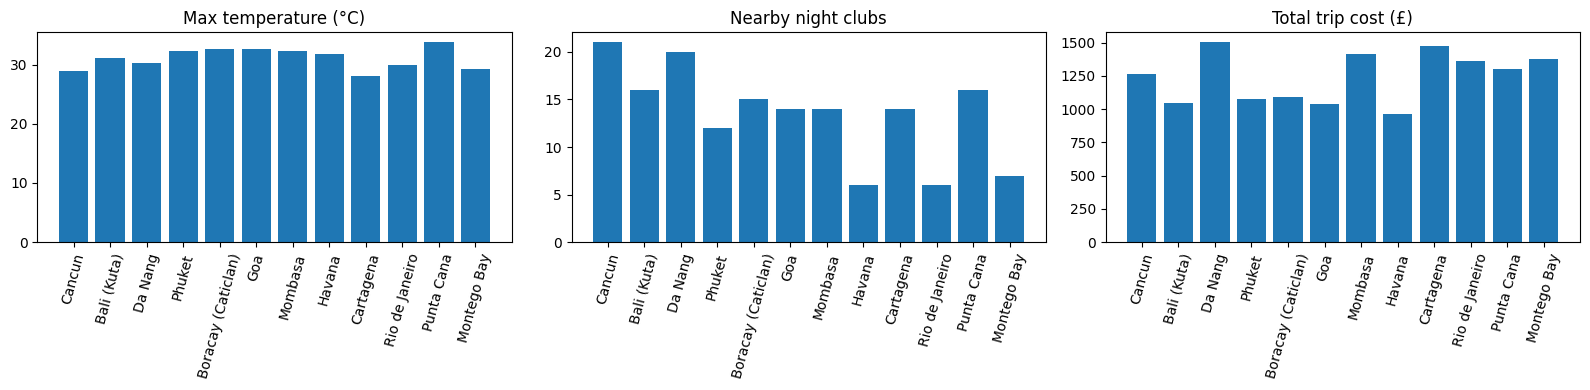

In [4]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
ax[0].bar(ranked['city'], ranked['temp_max']); ax[0].set_title('Max temperature (°C)'); ax[0].tick_params(axis='x', rotation=75)
ax[1].bar(ranked['city'], ranked['night_clubs']); ax[1].set_title('Nearby night clubs'); ax[1].tick_params(axis='x', rotation=75)
ax[2].bar(ranked['city'], ranked['total_cost']); ax[2].set_title('Total trip cost (£)'); ax[2].tick_params(axis='x', rotation=75)
plt.tight_layout(); plt.show()

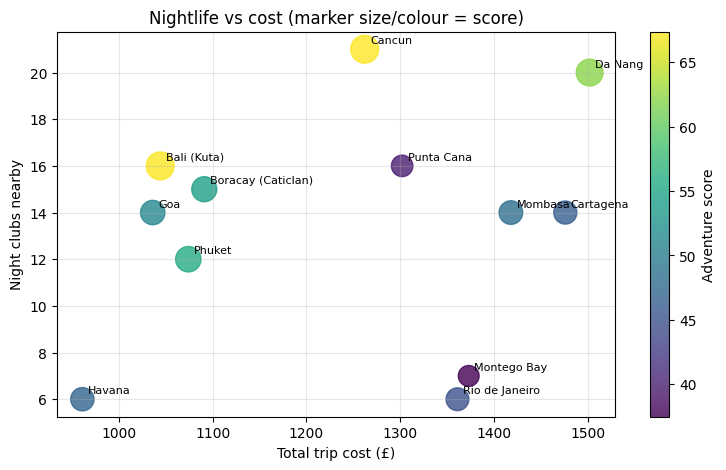

In [5]:
# Relationship: nightlife vs value, sized by score
plt.scatter(ranked['total_cost'], ranked['night_clubs'], s=ranked['adventure_score']*6,
            c=ranked['adventure_score'], cmap='viridis', alpha=.8)
for r in ranked.itertuples():
    plt.annotate(r.city, (r.total_cost, r.night_clubs), fontsize=8, xytext=(4,4), textcoords='offset points')
plt.colorbar(label='Adventure score'); plt.xlabel('Total trip cost (£)'); plt.ylabel('Night clubs nearby')
plt.title('Nightlife vs cost (marker size/colour = score)'); plt.grid(alpha=.3); plt.show()

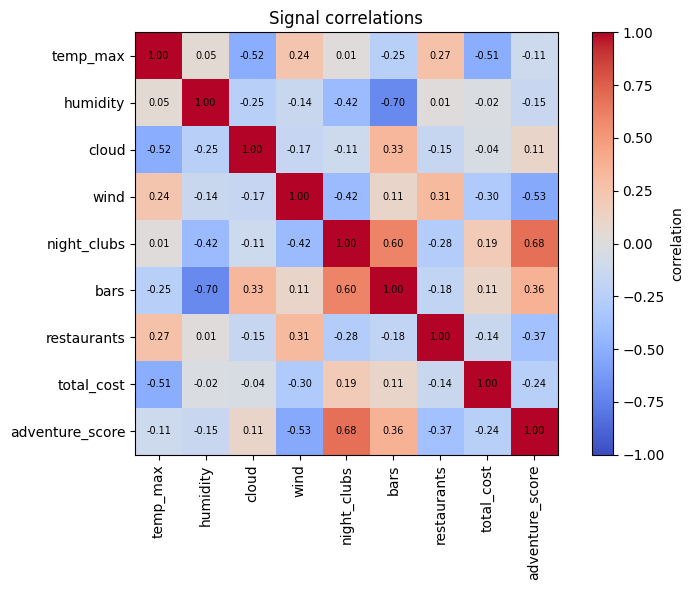

In [6]:
# Correlation of the numeric signals
cols=['temp_max','humidity','cloud','wind','night_clubs','bars','restaurants','total_cost','adventure_score']
import numpy as np
corr=ranked[cols].corr()
plt.figure(figsize=(8,6)); plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=90); plt.yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j,i,f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(label='correlation'); plt.title('Signal correlations'); plt.tight_layout(); plt.show()

**EDA observations.** Nightlife density (clubs/bars/restaurants) and value (lower total cost)
are the strongest drivers of the score, exactly as intended by the weighting. Temperature clusters
in the comfortable high-20s/low-30s °C band across this tropical shortlist, so it differentiates less.

## 4. The scoring model & sensitivity to preferences
The score is a transparent weighted blend; changing the weights changes the ranking.

In [7]:
def top3(weights):
    r = build_recommendations(weights=weights)
    return ', '.join(f"{c} ({s:.0f})" for c,s in zip(r['city'].head(3), r['adventure_score'].head(3)))

print('Balanced (default): ', top3(DEFAULT_WEIGHTS))
print('Nightlife-focused:  ', top3({**DEFAULT_WEIGHTS, 'nightlife':0.7, 'value':0.1}))
print('Budget-focused:     ', top3({**DEFAULT_WEIGHTS, 'value':0.6, 'nightlife':0.2}))

Balanced (default):  Cancun (67), Bali (Kuta) (67), Da Nang (62)
Nightlife-focused:   Cancun (73), Da Nang (69), Bali (Kuta) (64)
Budget-focused:      Bali (Kuta) (74), Havana (67), Phuket (64)


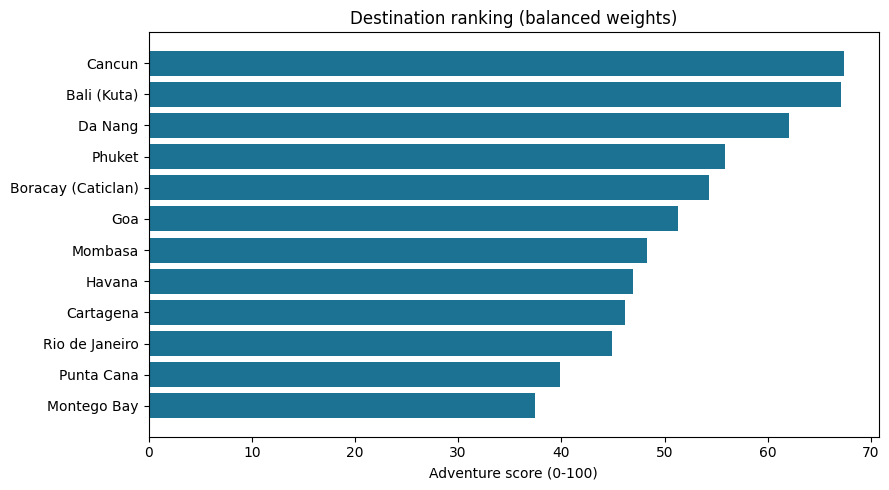

In [8]:
# Visualise the final ranking
plt.barh(ranked['city'][::-1], ranked['adventure_score'][::-1], color='#1C7293')
plt.xlabel('Adventure score (0-100)'); plt.title('Destination ranking (balanced weights)'); plt.tight_layout(); plt.show()

## 5. Map & heatmap

In [9]:
try:
    import folium
    from folium.plugins import HeatMap
    m = folium.Map(location=[10,20], zoom_start=2, tiles='cartodbpositron')
    HeatMap(ranked[['lat','lon','adventure_score']].values.tolist(), radius=25).add_to(m)
    for r in ranked.itertuples():
        folium.CircleMarker([r.lat,r.lon], radius=6, color='#065A82', fill=True,
            popup=f'{r.city} ({r.adventure_score:.0f})').add_to(m)
    m.save('holiday_planner_map.html'); print('Saved holiday_planner_map.html')
    m
except Exception as e:
    print('folium not available here; the app renders this live.', e)

Saved holiday_planner_map.html


## 6. Recommendation (LLM-assisted blurb)

In [10]:
print(recommend_blurb(ranked))

Top pick: Cancun, Mexico. With around 21 clubs and 56 bars nearby, warm 29°C weather and a competitive ~£1262 total trip cost, it offers the best balance of nightlife, climate and value among the options. Bali (Kuta) and Da Nang are strong runners-up if you want alternatives.


In [11]:
ranked.to_csv('holiday_recommendations.csv', index=False)
print('Saved holiday_recommendations.csv with', len(ranked), 'destinations')

Saved holiday_recommendations.csv with 12 destinations


## 7. Key findings, conclusions & lessons learned

**Key findings**
- For a nightlife-seeking traveller, **Da Nang, Cancún and Rio** lead the balanced ranking; the order
  shifts sensibly when the user prioritises budget or nightlife.
- **Nightlife density and value** dominate the recommendation; tropical temperature is a weaker
  differentiator because all candidates are warm.

**How LLMs were used**
- Curating the candidate shortlist and amenity descriptions, drafting the scoring rationale/weights,
  and generating the natural-language recommendation blurb. The numeric score stays deterministic.

**Conclusions**
- A small, transparent weighted model over live signals gives an explainable, user-tunable
  recommendation, delivered through a hosted app with maps and a heatmap.

**Lessons learned**
- Cache billable API calls (SQLite) and make every call fail-safe.
- Keep one shared pipeline for app + analysis to avoid drift.
- Explicit weights make recommendations defensible and easy to tune.

**Future work**
- Live flight-price APIs, a richer scraped-amenities layer, user accounts, and automated weekly refresh.